In [1]:
import os
from matplotlib import pyplot as plt
from torchvision import datasets , transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Load data

In [3]:
image_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness = 0.2,contrast = 0.2),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485,0.456,0.406],std = [0.229,0.214,0.225])
    
]
    
)

In [4]:
dataset_path = './dataset'
dataset = datasets.ImageFolder(root = dataset_path,transform = image_transform)
len(dataset)

2300

In [5]:
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [6]:
num_classes = len(dataset.classes)
num_classes

6

In [7]:
train_size = int(0.75 * len(dataset))
val_size = len(dataset) - train_size
train_size,val_size

(1725, 575)

In [8]:
from torch.utils.data import random_split
train_datset,val_dataset = random_split(dataset,[train_size,val_size])

In [9]:
train_loader = DataLoader(train_datset,batch_size = 32 ,shuffle = True)
val_loader = DataLoader(val_dataset,batch_size = 32 ,shuffle = True)

In [10]:
for images , labels  in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [11]:
images[0].shape

torch.Size([3, 224, 224])

In [12]:
labels[0]

tensor(1)

In [13]:
images[0].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0575407..1.8033988].


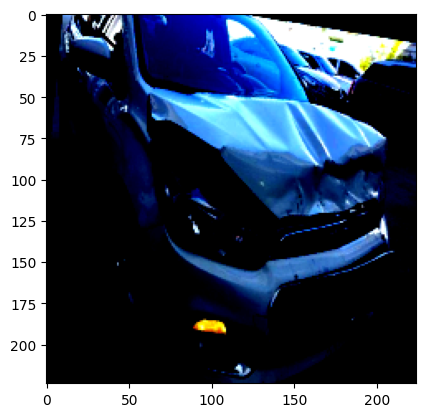

In [14]:
plt.imshow(images[0].permute(1,2,0))

In [ ]:
#define the objective function for optuna
def objective(trial):
    #suggest values for hyperparameters
    lr = trail.suggest_float('lr', 1e-5,1e-2,log = True)
    dropout_rate = trail.suggest_float('dropout_rate',0.2,0.7)

    #load the model
    model = CarClassifierResNet(num_classes= num_classes,dropout_rate = dropout_rate).to(device)

    # define the loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p : p.requires_grad ,model.parameters()),lr = lr)

    # training loop (using fewer epochs for faster hyperparameter tuning)
    epochs = 3
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num ,(images,labels) in enumerate(train_loader):
            
            images , labels = images.to(device),labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward Pass

            outputs = model(images)
            loss = criterion(outputs,labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            if (batch_num +1)% 10 ==0:
                print(f"Batch: {batch_num+1} , Epoch : {epoch +1} ,Loss : {loss.item():.2f}")
            

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch + 1}/{epochs}] , Avg Loss : {epoch_loss:.4f}")
    
        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels  = []
        all_predictions = []

         with torch.no_grad():
            for images, labels in val_loader:
                images , labels = images.to(device),labels.to(device)
                outputs = model(images)
                _,predicted = torch.max(outputs.data , 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
            print(f" *** Validation Accuracy : {100 * correct/total:.2f}% ***")

    end = time.time()
    print(f"Execution Time : {end- start} seconds")
    return all_labels , all_predictions
    
            

### Model 4 Transfer Learning with ResNet

In [ ]:
class CarClassifierResNet(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.model = models.resnet50(weights = 'DEFAULT')

        for param in self.model.parameters():
            param.requires_grad = False

        for param in self.model.layer4.parameters():
            param.requires_grad = True

        

        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.model.fc.in_features,num_classes)
        )

    def forward(self,x):
        x = self.model(x)
        return x

In [ ]:
model = CarClassifierResNet(num_classes= num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p : p.requires_grad ,model.parameters()),lr = 0.001)
all_labels , all_predictions = train_model(model,criterion , optimizer,epochs = 10)